# Beyond BLAST

In [122]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`


In [123]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
#include("blast_code/src/new_funcs.jl");

Main.blast_tutorials

In [124]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using FastTransforms
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using StaticArrays
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using .Blast
using .blast_tutorials;

### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [125]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

open("dimensions.txt", "w") do f
    write(f, "------------------------ \n")
    write(f, "IMPORTED REDSHIFT\n")
    write(f, "Redshift array z_b taken from background has dimensions: $(size(z_b))\n")
    write(f, "MIN = $(minimum(z_b)) || MAX = $(maximum(z_b)) \n")
    write(f, "------------------------ \n")
    write(f, "IMPORTED COMOVING DISTANCE\n")
    write(f, "Comoving distance array χ_b taken from background has dimensions: $(size(χ_b))\n")
    write(f, "MIN = $(minimum(χ_b)) || MAX = $(maximum(χ_b)) \n")
    write(f, "------------------------ \n")
    write(f, "INTERPOLATED QUANTITIES\n")
    write(f, "Redshift interpolated array z_of_χ has dimensions: $(size(z_of_χ(χ_b)))\n")
    write(f, "MIN = $(minimum(z_of_χ(χ_b))) || MAX = $(maximum(z_of_χ(χ_b))) \n")
    write(f, "Comoving distance interpolated array chi_of_z has dimensions: $(size(chi_of_z(z_b)))\n")
    write(f, "MIN = $(minimum(chi_of_z(z_b))) || MAX = $(maximum(chi_of_z(z_b))) \n")
    write(f, "------------------------ \n")
    write(f, "z_b = z_of_χ(χ_b) and x_b = chi_of_z(z_b), up to numerical precision.\n")
    write(f, "------------------------ \n")
end;

### Getting N5K quantities:

In [126]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_n5k = n5k_bins["z_cl"]
z_n5k = sort(z_n5k) # sort the redshift array in ascending order
n_z_matrix = n5k_bins["dNdz_cl"];

open("dimensions.txt", "a") do f
    write(f, "N5K QUANTITIES\n")
    write(f, "n5k_bins has columns: $(keys(n5k_bins))\n")
    write(f, "------------------------ \n")
    write(f, "dN/dz\n")
    write(f, "numerical density N5K dN/dz (for clustering) has dimensions: $(size(n5k_bins["dNdz_cl"]))\n")
    write(f, "MIN = $(minimum(n_z_matrix)) || MAX = $(maximum(n_z_matrix)) \n")
    write(f, "------------------------ \n")
    write(f, "REDSHIFT z\n")
    write(f, "redshift N5K z (for clustering) has dimensions: $(size(n5k_bins["z_cl"]))\n")
    write(f, "MIN = $(minimum(n5k_bins["z_cl"])) || MAX = $(maximum(n5k_bins["z_cl"])) \n")
    write(f, "------------------------ \n")
    write(f, "There are $(size(n5k_bins["z_cl"])[1]) redshift values for each of the $(size(n5k_bins["dNdz_cl"])[2]) bins.\n")
    write(f, "------------------------ \n")
end;

### Plotting the dN/dz distribution for each bin:

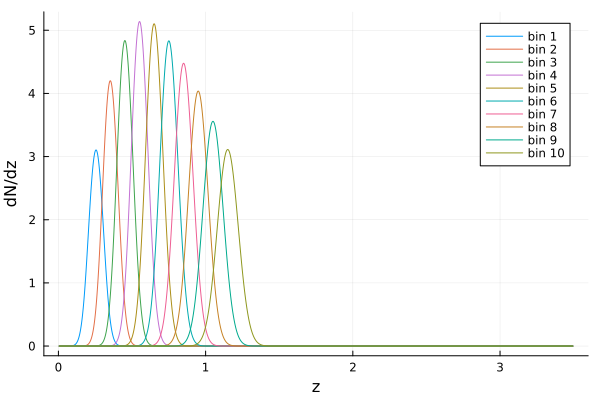

In [127]:
p = plot()
for i in 1:size(n_z_matrix, 2)
    plot!(p, z_n5k, n_z_matrix[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
display(p)

### Normalizing n(z)

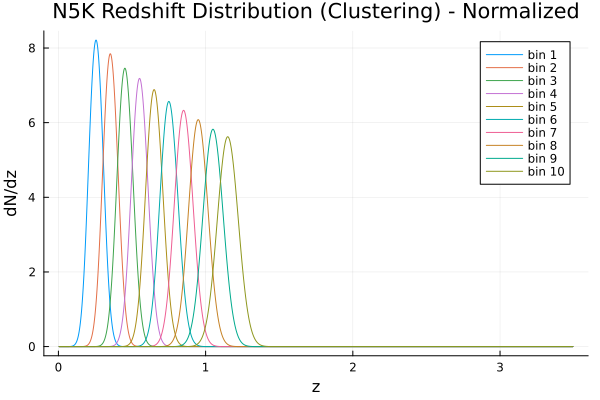

In [128]:
norms = [quadgk(x -> DataInterpolations.AkimaInterpolation(n_z_matrix[:, i], z_n5k, extrapolation=ExtrapolationType.Linear)(x),
                minimum(z_n5k), maximum(z_n5k))[1] for i in 1:size(n_z_matrix, 2)]
n_z_norm = n_z_matrix ./ reshape(norms, 1, :);

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "N5K dN/dz normalization\n")
    write(f, "The N5K dN/dz values for each bin are normalized such that the integral over redshift is 1.\n")
    write(f, "The norms used for normalization are: \n$(norms)\n")
    write(f, "------------------------ \n")
    write(f, "The normalized N5K dN/dz values for each bin have dimensions: \n$(size(n_z_norm))\n")
    write(f, "MIN = $(minimum(n_z_norm)) || MAX = $(maximum(n_z_norm)) \n")
end;

#### PLOTTING the results
p = plot()
for i in 1:size(n_z_norm, 2)
    plot!(p, z_n5k, n_z_norm[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
title!(p, "N5K Redshift Distribution (Clustering) - Normalized")
display(p)

### Creating redshift array and comoving distance array for N5K data

In [129]:
### REDSHIFT ARRAY
z_array = LinRange(minimum(z_n5k), maximum(z_n5k), size(z_n5k)[1]) # array of redshifts to evaluate n(z) on
#### COMOVING DISTANCES ARRAY
chi_array = chi_of_z.(z_array); # array of comoving distances corresponding to z_range

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "REDSHIFT ARRAY\n")
    write(f, "Redshift z_array is a vector or dimension: $(size(z_array))\n")
    write(f, "MIN = $(minimum(z_array)) || MAX = $(maximum(z_array))\n")
    write(f, "------------------------ \n")
    write(f, "COMOVING DISTANCE ARRAY\n")
    write(f, "Comoving distance chi_array is a vector or dimension: $(size(chi_array))\n")
    write(f, "MIN = $(minimum(chi_array)) || MAX = $(maximum(chi_array))\n")
    write(f, "------------------------ \n")
    write(f, "Values of normalized N5K dN/dz (clustering) for the first bin are: \n$(n_z_norm[:, 1])\n")
    write(f, "------------------------ \n")
end;

### Setting number of COMOVING DISTANCE POINTS

In [130]:
cosmo = Blast.FlatΛCDM()
n_chi = 96;                  # Number of comoving distance points

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "NUMBER OF COMOVING DISTANCE POINTS: $n_chi\n")
end;

### Defining redshift array and comoving distance array with our $\chi_{min}$ and $\chi_{max}$

In [131]:
# Array of comoving distances
x_array = LinRange(26, 7000, n_chi)
# Array of redshifts corresponding to the comoving distances
z_range = z_of_χ.(x_array);

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "COMOVING DISTANCES AND CORRESPONDING REDSHIFTS\n")
    write(f, "Array of comoving distances x_array has dimensions: $(size(x_array))\n")
    write(f, "MIN = $(minimum(x_array)) || MAX = $(maximum(x_array)) \n")
    write(f, "Array of redshifts z_range has dimensions: $(size(z_range))\n")
    write(f, "MIN = $(minimum(z_range)) || MAX = $(maximum(z_range)) \n")
    write(f, "------------------------ \n")
end;

### BIAS

In [132]:
###### BIAS ######
# compute the bias. the equation is b(z) = b_0 * sqrt(1+z). we set b_0 = 1.0.!
b_0 = 1.0
b_z_array = b_0 .* sqrt.(1 .+ z_range); # bias as a function of redshift

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "BIAS ARRAY\n")
    write(f, "Array of bias values b_z_array has dimensions: $(size(b_z_array))\n")
    write(f, "MIN = $(minimum(b_z_array)) || MAX = $(maximum(b_z_array)) \n")
  end;

### GROWTH FACTOR

In [133]:
###### GROWTH FACTOR ######
#i want to obtain the growth factor D(z) from the background quantities. i can use the cosmology package to compute this.
function heath_integral(cosmo, z)
    integrand(zp) = (1.0 + zp) / (Blast.compute_adimensional_hubble_factor(zp, cosmo)^3)
    integral_val, _ = quadgk(integrand, z, Inf, rtol=1e-8)
    return Blast.compute_adimensional_hubble_factor(z, cosmo) * integral_val
end
function compute_growth_factor(cosmo, z_range)
    D_unnorm_z0 = heath_integral(cosmo, 0.0)
    D_array = [heath_integral(cosmo, zz) / D_unnorm_z0 for zz in z_range]
    return D_array
end
# Array of growth factor values
growth_array = compute_growth_factor(cosmo, z_range);

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "BIAS ARRAY\n")
    write(f, "Array of bias values b_z_array has dimensions: $(size(b_z_array))\n")
    write(f, "MIN = $(minimum(b_z_array)) || MAX = $(maximum(b_z_array)) \n")
  end;

### PLOTTING BIAS $b(z)$, COMOVING DISTANCE $\chi(z)$, and GROWTH FACTOR $D(z)$

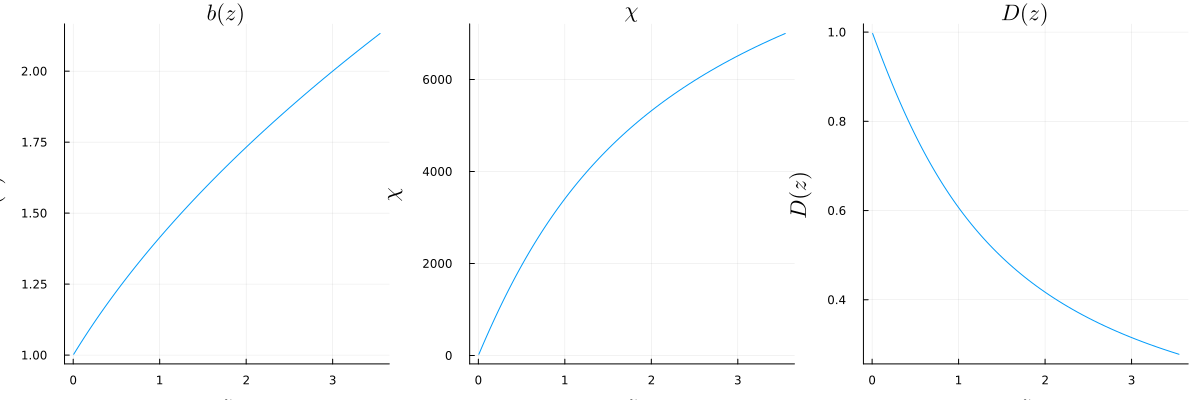

In [134]:
p1 = plot(z_range, 
          b_z_array, 
          label=L"$b(z)$", 
          xlabel=L"$z$", 
          ylabel=L"$b(z)$", 
          title=L"$b(z)$")
p2 = plot(z_range, 
          x_array, 
          label=L"z and $\chi$",
          title = L"$\chi$",
          xlabel=L"$z$", 
          ylabel=L"$\chi$")
p3 = plot(z_range, 
          growth_array, 
          label="Growth Factor D(z)", 
          xlabel=L"$z$", 
          ylabel=L"$D(z)$", 
          title=L"$D(z)$")
plot(p1, p2, p3, layout=(1,3), titlefontsize=15, labelfontsize=15, legendfontsize=15, size=(1200,400), legend=false)

In [135]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Array of redshifts: z_range has dimensions: $(size(z_range)) || z_array has dimensions: $(size(z_array))\n")
  end;

### GETTING $n(z)$

In [136]:
n_bins = size(n_z_norm, 2) # number of tomographic bins
nz = zeros(n_chi, n_bins) # size nx per number of bins
for b in 1:n_bins
     nz_func = DataInterpolations.AkimaInterpolation(n_z_norm[:, b], z_array, extrapolation=ExtrapolationType.Linear)
     nz_norm, _ = quadgk(nz_func, minimum(z_range), maximum(z_range), rtol=1e-8)
     #println("Bin $b: Normalized n(z) integral: ", nz_norm)
     nz[:, b] = nz_func.(z_range)
     #println("Bin $b: n(z) has size: ", size(nz))
end

open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Number of tomographic bins: $(n_bins)\n")
    write(f, "Size of n(z) array nz: $(size(nz))\n")
  end;

### GETTING the inverse of $H(z)$

In [137]:
inv_Hz_array = [1.0 / Blast.compute_adimensional_hubble_factor(z, cosmo) for z in z_range];

In [138]:
prefac = x_array.^2 .* b_z_array .* growth_array
kernel_composed = reshape(prefac, :, 1) .* nz .* inv_Hz_array;

In [139]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "Number of tomographic bins n_bins: $(n_bins)\n")
    write(f, "Size of n(z) array nz: $(size(nz))\n")
    write(f, "Size of prefactor array (chi^2 * b(z) * D(z)): $(size(prefac))\n")
    write(f, "Size of kernel_composed array: $(size(kernel_composed))\n")
    write(f, "The prefactor array is the product of chi^2, b(z), and D(z) evaluated at the redshifts corresponding to the comoving distances in x_array.\n")
    write(f, "Size of array z_range: $(size(z_range))\n")
    write(f, "Size of array x_array: $(size(x_array))\n")
    write(f, "Size of array b_z_array: $(size(b_z_array))\n")
    write(f, "Size of array growth_array: $(size(growth_array))\n")
    write(f, "Size of array nz: $(size(nz))\n")
  end;

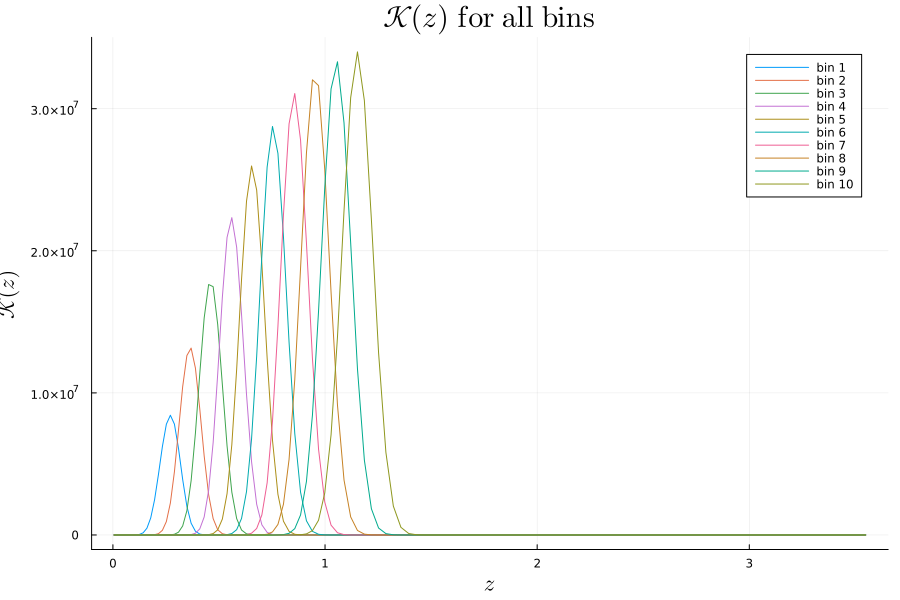

In [140]:
p = plot(
    xlabel=L"$z$",
    ylabel=L"\mathcal{K}(z)",
    title=L"\mathcal{K}(z)\ \mathrm{for\ all\ bins}",
    xlabelfontsize=15,
    ylabelfontsize=15,
    titlefontsize=20,
    legendfontsize=8,
    size=(900, 600)
)
for b in 1:size(kernel_composed, 2)
    plot!(p, z_range, kernel_composed[:, b], label="bin $b")
end
display(p)

In [141]:
ℓ = Blast.ℓ
x_min = 26                                            # minimum comoving distance
x_max = 7000                                          # maximum comoving distance
chi = LinRange(x_min, x_max, n_chi)                     # array of comoving distances
zed = z_of_χ.(chi)                                      # array of redshifts corresponding to the comoving distances
zmin = minimum(zed)                                     # minimum redshift
zmax = maximum(zed)                                     # maximum redshift
kmax = 200/13                                         # maximum wavenumber (small scales)
kmin = 2.5/x_max                                      # minimum wavenumber (large scales)
n_cheb = 119                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^(15)+1;                                         # number of integration points

In [142]:
println(z_array)

LinRange{Float64}(0.005833332, 3.494166, 2000)


In [143]:
# W_LL_A = zeros(length(ℓ), length(chi), length(chi), n_cheb + 1)
# W_LL_B = zeros(length(ℓ), length(chi), length(chi), n_cheb + 1)
# time_elapsed = @elapsed begin
#     for i in eachindex(ℓ)
#         W_LL_A[i,:,:,:] = Blast.compute_W̃(ℓ[i], chi, zed, kmin, kmax, zmin, zmax; n_cheb, N)
#         W_LL_B[i,:,:,:] = W_LL_A[i,:,:,:]
#         println("Computed W̃ for i = ", i)
#     end
# end
# println("Computation of W̃ for all ℓ values took: ", time_elapsed, " seconds.")

In [145]:
# #i want to save in a file all W_LL_A and W_LL_B values for all ℓ, chi and chi' in a .npy file. i can use the NPZ package to do this.
# npzwrite("W_LL_A.npy", W_LL_A)
# npzwrite("W_LL_B.npy", W_LL_B)
# I now want to upload them
W_LL_A = npzread("W_LL_A.npy")
W_LL_B = npzread("W_LL_B.npy");

In [146]:
println("Size of W_LL_A: ", size(W_LL_A))
println("Size of W_LL_B: ", size(W_LL_B))

Size of W_LL_A: (22, 96, 96, 120)
Size of W_LL_B: (22, 96, 96, 120)


In [ ]:
open("dimensions.txt", "a") do f
    write(f, "------------------------ \n")
    write(f, "INPUT PARAMETERS \n")
    write(f, "MIN COMOVING DISTANCE = $x_min, MAX COMOVING DISTANCE = $x_max, \n")
    write(f, "NUMBER OF COMOVING DISTANCE POINTS = $n_chi, \n")
    write(f, "NUMBER OF RATIOS R = $nR, \n")
    write(f, "MIN RATIO Rmin = $(minimum(R)), MAX RATIO Rmax = $(maximum(R)), \n")
    write(f, "MIN WAVENUMBER kmin = $kmin, MAX WAVENUMBER kmax = $kmax, \n")
    write(f, "NUMBER OF CHEBYSHEV NODES = $n_cheb, \n")
    write(f, "NUMBER OF INTEGRATION POINTS = $N, \n")
    write(f, "EXPONENT β = -2 for shear-shear, 0 for galaxy-shear and 2 for galaxy-galaxy \n")
  end;

In [ ]:
nk  = length(k_array)
nk1 = length(k1_array)
nk2 = length(k2_array)

W_base_k1 = zeros(Float64, length(ℓ), nk1, nk, n_cheb+1)
W_base_k2 = zeros(Float64, length(ℓ), nk2, nk, n_cheb+1)

computation_time = @elapsed begin
    for i in eachindex(ℓ)
        W_base_k1[i, :, :, :] = Blast.compute_W_tilde_modes(
            ℓ[i], k_array, k1_array, z_nodes, chi_interp, zmin, zmax;
            n_cheb=n_cheb, N=N
        )
        W_base_k2[i, :, :, :] = Blast.compute_W_tilde_modes(
            ℓ[i], k_array, k2_array, z_nodes, chi_interp, zmin, zmax;
            n_cheb=n_cheb, N=N
        )
    println("Computed W_tilde modes for i = $i")
    end
end
println("Total computation time for W_base_k1 and W_base_k2: ", computation_time, " seconds")

In [ ]:
# Now build W_tilde by contracting cheb coefficients with W_base (keeps bin dimension)
# W_base_k1 shape: (nl, nk1, nk, n_cheb) as allocated above
cheb_coef_Kt_padded = zeros(n_bins, n_cheb + 1)
cheb_coef_Kt_padded[:, 1:n_cheb] .= cheb_coef_Kt
# Resulting W_tilde_k1 shape: (nl, n_bins, nk1, nk)
if @isdefined cheb_coef_Kt
    W_tilde_k1 = @tullio W[li, b, ik1, ik] := cheb_coef_Kt_padded[b, n] * W_base_k1[li, ik1, ik, n]
    W_tilde_k2 = @tullio W[li, b, ik2, ik] := cheb_coef_Kt_padded[b, n] * W_base_k2[li, ik2, ik, n]
    println("Built W_tilde_k1 and W_tilde_k2 from cheb_coef_Kt. Shapes:")
    println(size(W_tilde_k1), " , ", size(W_tilde_k2))
end

K_t_vals_padded = zeros(n_cheb + 1, n_bins)
K_t_vals_padded[1:n_cheb, :] .= K_t_vals
# For debugging / validation: also form the product directly with the polynomial samples K_t_vals (if available)
if @isdefined K_t_vals
    # K_t_vals expected shape: (n_cheb, n_bins)
    # produce W_tilde_from_polys with the same index ordering (li, b, ik1, ik)
    W_tilde_k1_from_polys = @tullio W[li, b, ik1, ik] := K_t_vals_padded[n, b] * W_base_k1[li, ik1, ik, n]
    W_tilde_k2_from_polys = @tullio W[li, b, ik2, ik] := K_t_vals_padded[n, b] * W_base_k2[li, ik2, ik, n]
    println("Also built W_tilde_*_from_polys for comparison. Shapes:")
    println(size(W_tilde_k1_from_polys), " , ", size(W_tilde_k2_from_polys))
end

In [ ]:
print("Shape of the computed W_tilde: ", size(W_tilde_k1_from_polys), "\n")
print("Shape of the computed W_tilde: ", size(W_tilde_k2_from_polys), "\n")
print("Shape of the computed cheb_coef_Kt: ", size(cheb_coef_Kt), "\n")

In [ ]:
W_tilde_k1 = @tullio W[li, b, ik1, ik] := cheb_coef_Kt[b, n] * W_base_k1[li, ik1, ik, n]
W_tilde_k2 = @tullio W[li, b, ik2, ik] := cheb_coef_Kt[b, n] * W_base_k2[li, ik2, ik, n];

In [ ]:
li = 1
i_bin = 1

heatmap(1:nk1, 1:nk2,
    W_tilde_k1_from_polys[li, i_bin, :, :] ./ maximum(abs.(W_tilde_k1_from_polys[li, i_bin, :, :])),
    size = (500, 500),
    title = L"W_{\mathrm{base},k_1}(\ell=\text{first}, \mathrm{bin}=\text{first})",
    c = :roma,
    xlabel = L"k_1",
    ylabel = L"k_2",
    legend = :none,
    yguidefontsize = 15,
    xguidefontsize = 15,
    titlefontsize = 20)

## Now the Power Spectrum

In [ ]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

println("Dimension of k points: ", size(k)[1])
println("Dimension of Pklin: ", size(Pklin)[1])
println("Dimension of Pknonlin: ", size(Pknonlin)[1])

#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

plot(k, power_spectrum.(k, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10,
      size=(800,600),
      legendfontsize=10)


#N5K benchmarks
dtype = Float64

benchmark_gg = npzread("blast_code/data/benchmarks_nl_full_clgg.npz")
benchmark_ll = npzread("blast_code/data/benchmarks_nl_full_clss.npz")
benchmark_gl = npzread("blast_code/data/benchmarks_nl_full_clgs.npz")

#Extracting C_ℓ
gg = dtype.(benchmark_gg["cls"])
ll = dtype.(benchmark_ll["cls"])
gl = dtype.(benchmark_gl["cls"])
ell = dtype.(benchmark_gg["ls"])

#Reshaping them into the same Blast's format
gg_reshaped = zeros( dtype, length(ell), 10, 10)
ll_reshaped = zeros(dtype, length(ell), 5, 5)
gl_reshaped = zeros( dtype, length(ell), 10, 5)
counter = 1
for i in 1:10
    for j in i:10
        gg_reshaped[:,i,j] = gg[counter, :]
        gg_reshaped[:,j,i] = gg_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:5
    for j in i:5
        ll_reshaped[:,i,j] = ll[counter, :]
        ll_reshaped[:,j,i] = ll_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:10
    for j in 1:5
        gl_reshaped[:,i,j] = gl[counter, :]
        counter += 1
    end
end

In [ ]:
function compute_Sℓ(W_tilde_k1::AbstractArray,
                    W_tilde_k2::AbstractArray,
                    k_array::AbstractVector,
                    ℓ_list::AbstractVector;
                    normalization::Real = 1.0,
                    χ1::Real = 1000.0,
                    χ2::Real = 1000.0,
                    power_spectrum = power_spectrum)

    nk = length(k_array)

    @assert size(W_tilde_k1_from_polys, 1) == length(ℓ_list)
    @assert size(W_tilde_k2_from_polys, 1) == length(ℓ_list)
    @assert size(W_tilde_k1_from_polys, 2) == size(W_tilde_k2_from_polys, 2)
    @assert size(W_tilde_k1_from_polys, 3) == size(W_tilde_k2_from_polys, 3)
    @assert size(W_tilde_k1_from_polys, 4) == size(W_tilde_k2_from_polys, 4)
    @assert size(W_tilde_k1_from_polys, 4) == nk
    @assert isodd(nk) "Simpson integration requires an odd number of k samples."

    w_k = Blast.simpson_weight_array(nk)
    Δk = nk > 1 ? (last(k_array) - first(k_array)) / (nk - 1) : one(eltype(k_array))
    normalization = 2/pi
    Pk = power_spectrum_nl(k_array, χ1, χ2)
    integrand = normalization .* k_array.^2 .* Pk .* w_k .* Δk

    @tullio Sℓ[li, b, ik1, ik2] := integrand[m] *
        W_tilde_k1_from_polys[li, b, ik1, m] *
        W_tilde_k2_from_polys[li, b, ik2, m]

    return Sℓ
end

In [ ]:
println(length(k_array))
println(isodd(length(k_array)))
nk = 2 * floor(Int, length(k_array) / 2) + 1
k_array = range(first(k_array), last(k_array); length = nk) |> collect
println(size(W_tilde_k1_from_polys))
println(length(k_array))

In [ ]:
S_l = compute_Sℓ(
    W_tilde_k1_from_polys,
    W_tilde_k2_from_polys,
    k_array,
    ℓ;
    normalization = (2/pi),
    χ1 = x_array[1],
    χ2 = x_array[1],
    power_spectrum = power_spectrum_nl
)

println("Size of S_ell = ", size(S_l))

In [ ]:
# Quante modalità Chebyshev ha W_base?
println("size W_base_k1 = ", size(W_base_k1))   # (nl, nk1, nk, ???)
println("size cheb_coef_Kt = ", size(cheb_coef_Kt))  # (nbins, ???)

# Devono avere la stessa dimensione lungo n
println("n_cheb W_base = ", size(W_base_k1, 4))
println("n_cheb coeff  = ", size(cheb_coef_Kt, 2))


In [ ]:
ik1 = 1
ik2 = 1
nl = length(ℓ)

plots = Plots.Plot[]

for i_bin in 1:size(S_l, 2)
    p = plot(ℓ[1:nl], S_l[1:nl, i_bin, ik1, ik2],
             label = "Sℓ",
             title = "bin $i_bin",
             titlefontsize = 20,
             xlabel = L"$\ell$",
             ylabel = L"$S_\ell$",
             labelfontsize = 15)
    push!(plots, p)
end

ncols = ceil(Int, sqrt(size(S_l, 2)))
nrows = ceil(Int, size(S_l, 2) / ncols)

plot(plots..., layout = (nrows, ncols), size = (1400, 1000))

In [ ]:
i_bin = 10
ik1 = 1
ik2 = 1
nl = length(ℓ)

plot(ℓ[1:nl], S_l[1:nl, i_bin, ik1, ik2],
     label = "Sℓ",
     title = L"$S_\ell$",
     titlefontsize = 20,
     xlabel = L"$\ell$",
     ylabel = L"$S_\ell$",
     labelfontsize = 15)

In [ ]:
function contract_Sℓ(S_l, proj_k1, proj_k2)
    @assert size(S_l, 3) == length(proj_k1)
    @assert size(S_l, 4) == length(proj_k2)

    @tullio C[li, b] := proj_k1[ik1] * S_l[li, b, ik1, ik2] * proj_k2[ik2]
    return C
end

In [ ]:
i_bin = 10
nl = length(ℓ)
proj_k1 = ones(size(S_l, 3))
proj_k2 = ones(size(S_l, 4))

C_l_like = contract_Sℓ(S_l, proj_k1, proj_k2)
C_l_like = contract_Sℓ(S_l, proj_k1, proj_k2)

plot(ℓ[1:nl], C_l_like[1:nl, i_bin],
     label = "BLAST-like",
     title = L"$C_\ell$-like quantity",
     titlefontsize = 20,
     xlabel = L"$\ell$",
     ylabel = L"$C_\ell$",
     labelfontsize = 15)